<a href="https://colab.research.google.com/github/anushah-200/factcheck_AI_model_agnostic/blob/main/notebooks/13_day2_baseline_grouped_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import os


In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/factcheckAI/outputs/factcheck_clean_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (806, 19)

Columns:
['Question', 'Ground_Truth', 'Category', 'Type', 'Model', 'Response', 'SemanticSimilarity', 'BLEU', 'ROUGE1', 'ROUGEL', 'BERTScore', 'ResponseLength', 'GroundTruthLength', 'QuestionLength', 'LengthDifference', 'ResponseCharacters', 'AverageWordLength', 'Hallucination', 'Question_ID']


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique questions:", df["Question_ID"].nunique())

print("\nModel distribution:")
print(df["Model"].value_counts())

print("\nHallucination distribution:")
print(df["Hallucination"].value_counts())

print("\nQuestion_ID sample:")
print(df[["Question_ID", "Question", "Model", "Hallucination"]].head())


Missing values:
Question              0
Ground_Truth          0
Category              0
Type                  0
Model                 0
Response              0
SemanticSimilarity    0
BLEU                  0
ROUGE1                0
ROUGEL                0
BERTScore             0
ResponseLength        0
GroundTruthLength     0
QuestionLength        0
LengthDifference      0
ResponseCharacters    0
AverageWordLength     0
Hallucination         0
Question_ID           0
dtype: int64

Duplicate rows: 0

Unique questions: 389

Model distribution:
Model
OpenAI      279
DeepSeek    270
Groq        257
Name: count, dtype: int64

Hallucination distribution:
Hallucination
1    440
0    366
Name: count, dtype: int64

Question_ID sample:
  Question_ID                                           Question   Model  \
0        Q164  On what date was the Declaration of Independen...  OpenAI   
1        Q199      What color is the sun when viewed from space?  OpenAI   
2        Q226       What happens if 

In [5]:
features = [
    "Category",
    "Type",
    "ResponseLength",
    "QuestionLength",
    "ResponseCharacters",
    "AverageWordLength"
]

target = "Hallucination"

categorical_features = [
    "Category",
    "Type"
]

numerical_features = [
    "ResponseLength",
    "QuestionLength",
    "ResponseCharacters",
    "AverageWordLength"
]

print("Features used by classifier:")
for feature in features:
    print("-", feature)


Features used by classifier:
- Category
- Type
- ResponseLength
- QuestionLength
- ResponseCharacters
- AverageWordLength


In [6]:
def evaluate_model(model, X_train, X_test, y_train, y_test, split_name, model_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Split": split_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    cm = confusion_matrix(y_test, y_pred)

    return results, cm


In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numerical_features)
        ])),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numerical_features)
        ])),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numerical_features)
        ])),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ])
}


In [8]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


Training rows: 644
Testing rows: 162

Train class distribution:
Hallucination
1    0.546584
0    0.453416
Name: proportion, dtype: float64

Test class distribution:
Hallucination
1    0.54321
0    0.45679
Name: proportion, dtype: float64


In [9]:
all_results = []
confusion_matrices = {}

for model_name, model in models.items():

    result, cm = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Random",
        model_name
    )

    all_results.append(result)
    confusion_matrices[("Random", model_name)] = cm

random_results = pd.DataFrame(all_results)

random_results


,Split,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random,Logistic Regression,0.820988,0.824176,0.852273,0.837989,0.910627
1,Random,Decision Tree,0.833333,0.801980,0.920455,0.857143,0.825092
2,Random,Random Forest,0.864198,0.851064,0.909091,0.879121,0.929899


In [10]:
import os
BASE = "/content/drive/MyDrive/factcheckAI/outputs/"

SPLIT_FILE = BASE + "canonical_question_split.csv"

if os.path.exists(SPLIT_FILE):
    split_lookup = pd.read_csv(SPLIT_FILE)
    df_split = df.merge(split_lookup, on="Question_ID", how="left")
    print("Loaded existing canonical split.")
else:
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=42
    )
    train_idx, test_idx = next(
        gss.split(
            df[features],
            df[target],
            groups=df["Question_ID"]
        )
    )

    split_lookup = df[["Question_ID"]].copy()
    split_lookup["Split"] = "train"
    split_lookup.loc[test_idx, "Split"] = "test"
    split_lookup = split_lookup.drop_duplicates(subset="Question_ID").reset_index(drop=True)
    split_lookup.to_csv(SPLIT_FILE, index=False)

    df_split = df.merge(split_lookup, on="Question_ID", how="left")
    print("Created and saved new canonical split.")

train_df = df_split[df_split["Split"] == "train"].drop(columns=["Split"]).copy()
test_df = df_split[df_split["Split"] == "test"].drop(columns=["Split"]).copy()

assert len(set(train_df["Question_ID"]) & set(test_df["Question_ID"])) == 0, "Question leakage detected!"

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Loaded existing canonical split.
Training rows: 653
Testing rows: 153


In [11]:
train_questions = set(train_df["Question_ID"])
test_questions = set(test_df["Question_ID"])

overlap = train_questions.intersection(test_questions)

print("Training questions:", len(train_questions))
print("Testing questions:", len(test_questions))
print("Question overlap:", len(overlap))


Training questions: 311
Testing questions: 78
Question overlap: 0


In [12]:
X_train_grouped = train_df[features]
y_train_grouped = train_df[target]

X_test_grouped = test_df[features]
y_test_grouped = test_df[target]

print("Grouped train class distribution:")
print(y_train_grouped.value_counts(normalize=True))

print("\nGrouped test class distribution:")
print(y_test_grouped.value_counts(normalize=True))


Grouped train class distribution:
Hallucination
1    0.542113
0    0.457887
Name: proportion, dtype: float64

Grouped test class distribution:
Hallucination
1    0.562092
0    0.437908
Name: proportion, dtype: float64


In [13]:
grouped_results = []

for model_name, model in models.items():

    result, cm = evaluate_model(
        model,
        X_train_grouped,
        X_test_grouped,
        y_train_grouped,
        y_test_grouped,
        "Question-Grouped",
        model_name
    )

    grouped_results.append(result)
    confusion_matrices[("Question-Grouped", model_name)] = cm

grouped_results_df = pd.DataFrame(grouped_results)

grouped_results_df


,Split,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Question-Grouped,Logistic Regression,0.790850,0.800000,0.837209,0.818182,0.874176
1,Question-Grouped,Decision Tree,0.758170,0.763441,0.825581,0.793296,0.748612
2,Question-Grouped,Random Forest,0.797386,0.795699,0.860465,0.826816,0.892051


In [14]:


rf_pipeline = models["Random Forest"]

# Get fitted Random Forest
rf_model = rf_pipeline.named_steps["classifier"]

# Get fitted preprocessor
preprocessor = rf_pipeline.named_steps["preprocessor"]

# Get transformed feature names
transformed_features = preprocessor.get_feature_names_out()

# Get feature importances
raw_importances = rf_model.feature_importances_

# Aggregate one-hot encoded features
aggregated_importance = {}

for feature_name, importance in zip(
    transformed_features,
    raw_importances
):

    if "Category" in feature_name:
        original_feature = "Category"

    elif "Type" in feature_name:
        original_feature = "Type"

    elif "ResponseLength" in feature_name:
        original_feature = "ResponseLength"

    elif "QuestionLength" in feature_name:
        original_feature = "QuestionLength"

    elif "ResponseCharacters" in feature_name:
        original_feature = "ResponseCharacters"

    elif "AverageWordLength" in feature_name:
        original_feature = "AverageWordLength"

    else:
        original_feature = feature_name

    aggregated_importance[original_feature] = (
        aggregated_importance.get(original_feature, 0)
        + importance
    )

importance_df = pd.DataFrame(
    list(aggregated_importance.items()),
    columns=["Feature", "Importance"]
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Convert to percentage
importance_df["Importance_Percentage"] = (
    importance_df["Importance"] * 100
)

print("===== FEATURE IMPORTANCE =====")
display(importance_df)

===== FEATURE IMPORTANCE =====


,Feature,Importance,Importance_Percentage
0,Category,0.492741,49.274134
1,ResponseCharacters,0.135320,13.531991
2,QuestionLength,0.129784,12.978368
3,ResponseLength,0.115828,11.582758
4,AverageWordLength,0.100452,10.045248
5,Type,0.025875,2.587501


In [15]:
results_df = pd.concat(
    [
        random_results,
        grouped_results_df
    ],
    ignore_index=True
)

results_df


,Split,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random,Logistic Regression,0.820988,0.824176,0.852273,0.837989,0.910627
1,Random,Decision Tree,0.833333,0.801980,0.920455,0.857143,0.825092
2,Random,Random Forest,0.864198,0.851064,0.909091,0.879121,0.929899
3,Question-Grouped,Logistic Regression,0.790850,0.800000,0.837209,0.818182,0.874176
4,Question-Grouped,Decision Tree,0.758170,0.763441,0.825581,0.793296,0.748612
5,Question-Grouped,Random Forest,0.797386,0.795699,0.860465,0.826816,0.892051


In [16]:
OUTPUT_PATH = "/content/drive/MyDrive/factcheckAI/outputs/day2_baseline_results.csv"

results_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved:", OUTPUT_PATH)


Saved: /content/drive/MyDrive/factcheckAI/outputs/day2_baseline_results.csv


In [17]:
print("===== FINAL RESULTS =====")
display(results_df)

print("\n===== SHAPE =====")
print(results_df.shape)

print("\n===== MISSING VALUES =====")
print(results_df.isnull().sum())

print("\n===== GROUPED SPLIT LEAKAGE CHECK =====")
print("Question overlap:", len(overlap))

print("\n===== FEATURES USED =====")
print(features)

print("\n===== OUTPUT EXISTS =====")
print(os.path.exists(OUTPUT_PATH))


===== FINAL RESULTS =====


,Split,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random,Logistic Regression,0.820988,0.824176,0.852273,0.837989,0.910627
1,Random,Decision Tree,0.833333,0.801980,0.920455,0.857143,0.825092
2,Random,Random Forest,0.864198,0.851064,0.909091,0.879121,0.929899
3,Question-Grouped,Logistic Regression,0.790850,0.800000,0.837209,0.818182,0.874176
4,Question-Grouped,Decision Tree,0.758170,0.763441,0.825581,0.793296,0.748612
5,Question-Grouped,Random Forest,0.797386,0.795699,0.860465,0.826816,0.892051



===== SHAPE =====
(6, 7)

===== MISSING VALUES =====
Split        0
Model        0
Accuracy     0
Precision    0
Recall       0
F1           0
ROC_AUC      0
dtype: int64

===== GROUPED SPLIT LEAKAGE CHECK =====
Question overlap: 0

===== FEATURES USED =====
['Category', 'Type', 'ResponseLength', 'QuestionLength', 'ResponseCharacters', 'AverageWordLength']

===== OUTPUT EXISTS =====
True


In [18]:
display(results_df)


,Split,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random,Logistic Regression,0.820988,0.824176,0.852273,0.837989,0.910627
1,Random,Decision Tree,0.833333,0.801980,0.920455,0.857143,0.825092
2,Random,Random Forest,0.864198,0.851064,0.909091,0.879121,0.929899
3,Question-Grouped,Logistic Regression,0.790850,0.800000,0.837209,0.818182,0.874176
4,Question-Grouped,Decision Tree,0.758170,0.763441,0.825581,0.793296,0.748612
5,Question-Grouped,Random Forest,0.797386,0.795699,0.860465,0.826816,0.892051


In [19]:
print("=== RANDOM SPLIT ===")
print("Train:")
print(y_train.value_counts())
print("\nTest:")
print(y_test.value_counts())

print("\n=== QUESTION-GROUPED SPLIT ===")
print("Train:")
print(y_train_grouped.value_counts())
print("\nTest:")
print(y_test_grouped.value_counts())

print("\n=== QUESTION LEAKAGE ===")
print("Overlap:", len(overlap))

print("\n=== FEATURES ===")
print(features)

print("\n=== RESULTS FILE ===")
print(OUTPUT_PATH)


=== RANDOM SPLIT ===
Train:
Hallucination
1    352
0    292
Name: count, dtype: int64

Test:
Hallucination
1    88
0    74
Name: count, dtype: int64

=== QUESTION-GROUPED SPLIT ===
Train:
Hallucination
1    354
0    299
Name: count, dtype: int64

Test:
Hallucination
1    86
0    67
Name: count, dtype: int64

=== QUESTION LEAKAGE ===
Overlap: 0

=== FEATURES ===
['Category', 'Type', 'ResponseLength', 'QuestionLength', 'ResponseCharacters', 'AverageWordLength']

=== RESULTS FILE ===
/content/drive/MyDrive/factcheckAI/outputs/day2_baseline_results.csv


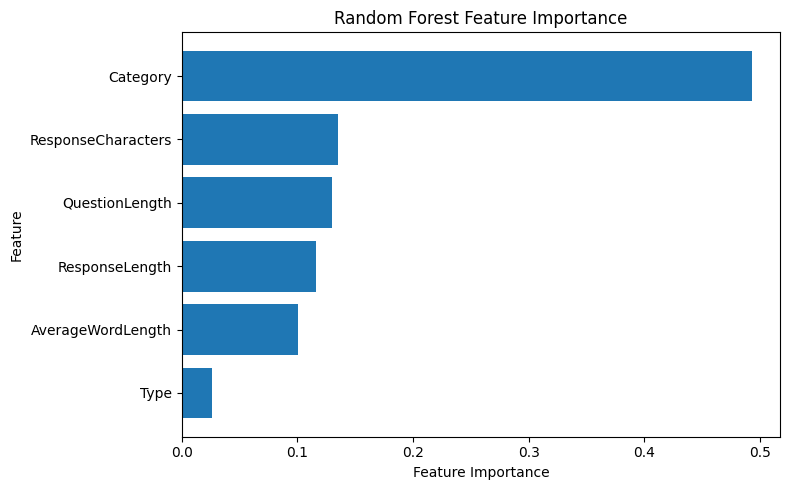

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [21]:
IMPORTANCE_PATH = BASE + "question_grouped_feature_importance.csv"

importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)

print("Saved:", IMPORTANCE_PATH)

Saved: /content/drive/MyDrive/factcheckAI/outputs/question_grouped_feature_importance.csv
